# Object Following - Live Demo

In this notebook we'll show how you can follow an object with JetBot!  We'll use a pre-trained neural network
that was trained on the [COCO dataset](http://cocodataset.org) to detect 90 different common objects.  These include

* Person (index 0)
* Cup (index 47)

and many others (you can check [this file](https://github.com/tensorflow/models/blob/master/research/object_detection/data/mscoco_complete_label_map.pbtxt) for a full list of class indices).  The model is sourced from the [TensorFlow object detection API](https://github.com/tensorflow/models/tree/master/research/object_detection),
which provides utilities for training object detectors for custom tasks also!  Once the model is trained, we optimize it using NVIDIA TensorRT on the Jetson Nano.

This makes the network very fast, capable of real-time execution on Jetson Nano!  We won't run through all of the training and optimization steps in this notebook though.

Anyways, let's get started.  First, we'll want to import the ``ObjectDetector`` class which takes our pre-trained SSD engine.

### Compute detections on single camera image

Internally, the ``ObjectDetector`` class uses the TensorRT Python API to execute the engine that we provide.  It also takes care of preprocessing the input to the neural network, as
well as parsing the detected objects.  Right now it will only work for engines created using the ``jetbot.ssd_tensorrt`` package. That package has the utilities for converting
the model from the TensorFlow object detection API to an optimized TensorRT engine.

Next, let's initialize our camera.  Our detector takes 300x300 pixel input, so we'll set this when creating the camera.

> Internally, the Camera class uses GStreamer to take advantage of Jetson Nano's Image Signal Processor (ISP).  This is super fast and offloads
> a lot of the resizing computation from the CPU. 

In [1]:
from jetbot import Camera

camera = Camera.instance(width=300, height=300)

Error loading module `qwiic_kx13x`: (unicode error) 'utf-8' codec can't decode byte 0xa0 in position 173: invalid start byte (qwiic_kx13x.py, line 328)
Invalid driver class name. Unable to locate QwiicAs6212
GST_ARGUS: Creating output stream
CONSUMER: Waiting until producer is connected...
GST_ARGUS: Available Sensor modes :
GST_ARGUS: 3280 x 2464 FR = 21.000000 fps Duration = 47619048 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 3280 x 1848 FR = 28.000001 fps Duration = 35714284 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1920 x 1080 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1640 x 1232 FR = 29.999999 fps Duration = 33333334 ; Analog Gain range min 1.000000, max 10.625000; Exposure Range min 13000, max 683709000;

GST_ARGUS: 1280 x 720 FR = 59.999999 fps Duration = 16666667 

[ WARN:0] global /home/ubuntu/build_opencv/opencv/modules/videoio/src/cap_gstreamer.cpp (1100) open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1


In [2]:
from jetbot import Robot

robot = Robot()

In [3]:
from nanoowl.owl_predictor import (OwlPredictor)
from nanoowl.owl_drawing import (draw_owl_output)

model = "google/owlvit-base-patch32"
image_encoder_engine = "/home/kimbring2/nanoowl/data/owl_image_encoder_patch32.engine"
predictor = OwlPredictor(model, image_encoder_engine=image_encoder_engine)

/home/kimbring2/.local/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[01/28/2024-21:46:38] [TRT] [W] Using an engine plan file across different models of devices is not recommended and is likely to affect performance or even cause errors.


Now, let's execute our network using some camera input.  By default the ``ObjectDetector`` class expects ``bgr8`` format that the camera produces.  However,
you could override the default pre-processing function if your input is in a different format.

In [8]:
from PIL import Image
import numpy as np

prompt = "[a stop sign, a can]"
threshold = 0.1
num_profiling_runs = 30

prompt = prompt.strip("][()")
text = prompt.split(',')
print(text)
image = Image.fromarray(np.uint8(camera.value))
text_encodings = predictor.encode_text(text)
detections = predictor.predict(image=image, text=text, text_encodings=text_encodings, threshold=threshold, pad_square=False)
print("detections: ", detections)

['a stop sign', ' a can']
detections:  OwlDecodeOutput(labels=tensor([0, 1], device='cuda:0'), scores=tensor([0.1380, 0.1123], device='cuda:0', grad_fn=<IndexBackward0>), boxes=tensor([[209.0332, 119.6045, 225.4395, 142.0166],
        [ 67.3462, 148.9746,  79.2480, 188.5254]], device='cuda:0'), input_indices=tensor([0, 0], device='cuda:0'))


In [9]:
import matplotlib.pyplot as plt

def get_colors(count: int):
    cmap = plt.cm.get_cmap("rainbow", count)
    colors = []
    for i in range(count):
        color = cmap(i)
        color = [int(255 * value) for value in color]
        colors.append(tuple(color))
        
    return colors

colors = get_colors(len(text))
num_detections = len(detections.labels)

for i in range(num_detections):
    label_index = int(detections.labels[i])
    label_text = text[label_index]
    bbox = detections.boxes[i]

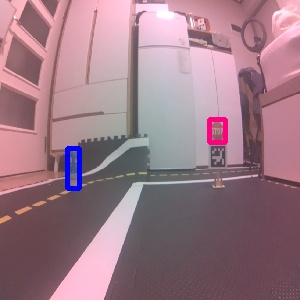

In [10]:
from IPython.display import display, HTML, clear_output
from IPython.display import Image as IPython_Image
import cv2

def arrayShow(imageArray):
    image = bytes(cv2.imencode('.jpg', imageArray)[1])
    return IPython_Image(data=image)

open_cv_image = np.array(image)
open_cv_image = open_cv_image[:, :, ::-1].copy()
open_cv_image = cv2.cvtColor(open_cv_image, cv2.COLOR_BGR2RGB)

for i in range(num_detections):
    box = detections.boxes[i]
    label_index = int(detections.labels[i])
    box = [int(x) for x in box]
    pt0 = (box[0], box[1])
    pt1 = (box[2], box[3])
    cv2.rectangle(open_cv_image, pt0, pt1, colors[label_index], 4)

arrayShow(open_cv_image)

In [11]:
def detection_center(bbox):
    """Computes the center x, y coordinates of the object"""
    center_x = (bbox[0] + bbox[2]) / 2.0 - 150.0
    center_y = (bbox[1] + bbox[3]) / 2.0 - 150.0
    return (center_x, center_y)


def norm(vec):
    """Computes the length of the 2D vector"""
    return np.sqrt(vec[0].detach().cpu().numpy()**2 + vec[1].detach().cpu().numpy()**2)


def closest_detection(detections):
    """Finds the detection closest to the image center"""
    closest_detection_label = None
    closest_detection_bbox = None
    
    num_detections = len(detections.labels)
    for i in range(num_detections):
        center = detection_center(detections.boxes[i])
        
        if closest_detection_bbox is None:
            closest_detection_label = detections.labels[i]
            closest_detection_bbox = detections.boxes[i]
        elif norm(detection_center(detections.boxes[i])) < norm(detection_center(closest_detection_bbox)):
            closest_detection_label = detections.labels[i]
            closest_detection_bbox = detections.boxes[i]
            
    return closest_detection_label, closest_detection_bbox

center[0]:  tensor(67.2363, device='cuda:0')
center[1]:  tensor(-19.1895, device='cuda:0')


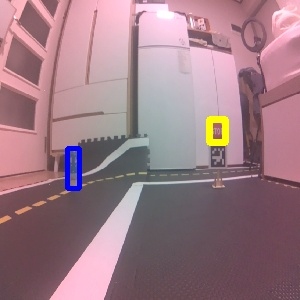

In [12]:
closest_det_label, closest_det_bbox = closest_detection(detections)

center = detection_center(closest_det_bbox)
print("center[0]: ", center[0])
print("center[1]: ", center[1])

if closest_det_label is not None:
    bbox = closest_det_bbox
    cv2.rectangle(open_cv_image, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), 
                  (0, 255, 255), 5)

arrayShow(open_cv_image)

If there are any COCO objects in the camera's field of view, they should now be stored in the ``detections`` variable.

### Display detections in text area

We'll use the code below to print out the detected objects.

In [13]:
from IPython.display import display
import ipywidgets.widgets as widgets

detections_widget = widgets.Textarea()

detections_widget.value = str(detections)

display(detections_widget)

Textarea(value="OwlDecodeOutput(labels=tensor([0, 1], device='cuda:0'), scores=tensor([0.1380, 0.1123], device…

You should see the label, confidence, and bounding box of each object detected in each image.  There's only one image (our camera) in this example. 


To print just the first object detected in the first image, we could call the following

> This may throw an error if no objects are detected

In [14]:
image_number = 0
object_number = 0

print((detections.labels)[image_number])

tensor(0, device='cuda:0')


### Control robot to follow central object

Now we want our robot to follow an object of the specified class.  To do this we'll do the following

1.  Detect objects matching the specified class
2.  Select object closest to center of camera's field of vision, this is the 'target' object
3.  Steer robot towards target object, otherwise wander
4.  If we're blocked by an obstacle, turn left

We'll also create some widgets that we'll use to control the target object label, the robot speed, and
a "turn gain", that will control how fast the robot turns based off the distance between the target object
and the center of the robot's field of view. 


First, let's load our collision detection model.  The pre-trained model is stored in this directory as a convenience, but if you followed
the collision avoidance example you may want to use that model if it's better tuned for your robot's environment.

In [15]:
import torch
import torchvision
import torch.nn.functional as F
import cv2
import numpy as np

collision_model = torchvision.models.alexnet(pretrained=False)
collision_model.classifier[6] = torch.nn.Linear(collision_model.classifier[6].in_features, 2)
collision_model.load_state_dict(torch.load('../collision_avoidance/best_model.pth'))
device = torch.device('cuda')
collision_model = collision_model.to(device)

mean = 255.0 * np.array([0.485, 0.456, 0.406])
stdev = 255.0 * np.array([0.229, 0.224, 0.225])

normalize = torchvision.transforms.Normalize(mean, stdev)

def preprocess(camera_value):
    global device, normalize
    x = camera_value
    x = cv2.resize(x, (224, 224))
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    x = x.transpose((2, 0, 1))
    x = torch.from_numpy(x).float()
    x = normalize(x)
    x = x.to(device)
    x = x[None, ...]
    return x

/home/kimbring2/.local/lib/python3.8/site-packages/torchvision-0.15.1a0+42759b1-py3.8-linux-aarch64.egg/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kimbring2/.local/lib/python3.8/site-packages/torchvision-0.15.1a0+42759b1-py3.8-linux-aarch64.egg/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Great, now let's initialize our robot so we can control the motors.

In [2]:
from jetbot import Robot

robot = Robot()

ModuleNotFoundError: No module named 'Jetbot'

Finally, let's display all the control widgets and connect the network execution function to the camera updates.

In [16]:
from jetbot import bgr8_to_jpeg

blocked_widget = widgets.FloatSlider(min=0.0, max=1.0, value=0.0, description='blocked')
image_widget = widgets.Image(format='jpeg', width=300, height=300)
prompt_widget = widgets.Text(value='[a can, a mug cup]', placeholder='Type something', description='detected object names', disabled=False)                          
speed_widget = widgets.FloatSlider(value=0.1, min=0.0, max=0.5, description='speed')
turn_gain_widget = widgets.FloatSlider(value=0.4, min=0.0, max=1.0, description='turn gain')

display(widgets.VBox([
    widgets.HBox([image_widget, blocked_widget]),
    prompt_widget,
    speed_widget,
    turn_gain_widget
]))

width = int(image_widget.width)
height = int(image_widget.height)

        
def execute(change):
    image = change['new']

    # execute collision model to determine if blocked
    collision_output = collision_model(preprocess(image)).detach().cpu()
    prob_blocked = float(F.softmax(collision_output.flatten(), dim=0)[0])
    blocked_widget.value = prob_blocked

    # turn left if blocked
    if prob_blocked > 0.25:
        robot.left(0.1)
        image_widget.value = bgr8_to_jpeg(image)
        return
    
    ##############################################################################
    prompt = prompt_widget.value
    prompt = prompt.strip("][()")
    text = prompt.split(',')
    
    pil_image = Image.fromarray(np.uint8(image))
    text_encodings = predictor.encode_text(text)
    detections = predictor.predict(image=pil_image, text=text, text_encodings=text_encodings, threshold=threshold, pad_square=False)

    num_detections = len(detections.labels)

    for i in range(num_detections):
        box = detections.boxes[i]
        label_index = int(detections.labels[i])
        box = [int(x) for x in box]
        pt0 = (box[0], box[1])
        pt1 = (box[2], box[3])
        cv2.rectangle(image, pt0, pt1, colors[label_index], 4)

    closest_det_label, closest_det_bbox = closest_detection(detections)
    if closest_det_label is not None:
        bbox = closest_det_bbox
        cv2.rectangle(image, (int(bbox[0]), int(bbox[1])), (int(bbox[2]), int(bbox[3])), (0, 255, 255), 5)

    # otherwise go forward if no target detected
    if closest_det_label is None:
        robot.forward(float(speed_widget.value))
    # otherwise steer towards target
    else:
        # move robot forward and steer proportional target's x-distance from center
        center = detection_center(closest_det_bbox)
        robot.set_motors(
            float(speed_widget.value - turn_gain_widget.value * center[0].detach().cpu().numpy() / float(width)),
            float(speed_widget.value + turn_gain_widget.value * center[0].detach().cpu().numpy() / float(height))
        )
    
    ##############################################################################
    
    # update image widget
    image_widget.value = bgr8_to_jpeg(image)
    
execute({'new': camera.value})

Call the block below to connect the execute function to each camera frame update.

In [17]:
camera.unobserve_all()
camera.observe(execute, names='value')

In [14]:
robot.stop()

Awesome!  If the robot is not blocked you should see boxes drawn around the detected objects in blue.  The target object (which the robot follows) will be displayed in green.

The robot should steer towards the target when it is detected.  If it is blocked by an object it will simply turn left.

You can call the code block below to manually disconnect the processing from the camera and stop the robot.

In [ ]:
import time

camera.unobserve_all()
time.sleep(1.0)
robot.stop()

Again, let's close the camera conneciton properly so that we can use the camera in other notebooks.

In [ ]:
camera.stop()